<a href="https://colab.research.google.com/github/RafihaikalP/BigData26_A_2411532002_Rafi-Haikal-Pratama/blob/main/Praktikum3/BD_P03_Tugas_2411532002_RafiHaikalPratama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tugas Praktikum Big Data — Pertemuan 3



## Setup: Import, Mount Drive, dan Definisi Ulang Fungsi

In [ ]:
import sys, time, os, json, sqlite3, gc, calendar
import pandas as pd
import numpy as np
import psutil
import requests
import shutil
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"
DIR_TUGAS  = "/content/drive/MyDrive/BigData/Tugas3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN, DIR_TUGAS):
    os.makedirs(d, exist_ok=True)

# Fungsi utilitas
proses  = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil   = fungsi()
    detik   = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik,2), "delta_rss_mb": round(rss_mb()-m0,1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

print("Utilitas siap.")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Utilitas siap.


In [ ]:
# ── Konstanta ─────────────────────────────────────────────────────────────────
KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count",      "trip_distance",
    "PULocationID",         "DOLocationID",
    "payment_type",         "fare_amount",
    "tip_amount",           "total_amount",
]

KUNCI = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "total_amount",
]

KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance"       : "float64",
    "durasi_menit"        : "float64",
    "total_amount"        : "float64",
    "borough_naik"        : "object",
    "nama_pembayaran"     : "object",
}

URL_ZONA  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

# ── Fungsi ────────────────────────────────────────────────────────────────────
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"  ✓ cache: {os.path.basename(tujuan)}")
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    shutil.copyfileobj(r.raw, f)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)
            print(f"  ✓ unduh: {os.path.basename(tujuan)}")
            return tujuan
        except Exception as e:
            time.sleep(jeda_awal * (2 ** i))
    raise RuntimeError(f"gagal unduh: {url}")

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    param = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=param, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:
                raise ValueError("kunci 'hourly' tidak ada")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):
            time.sleep(2 ** i); continue
        r.raise_for_status()
    raise RuntimeError("API cuaca gagal")

def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
    jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c"   : np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm" : np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe salah {kol}: {df[kol].dtype} ≠ {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n" + "\n".join(masalah))
    print(f"✓ Validasi lulus: {len(df):,} baris × {df.shape[1]} kolom")
    return df

print("Konstanta dan fungsi siap.")


Konstanta dan fungsi siap.


In [ ]:
# ── Setup database & tabel referensi ──────────────────────────────────────────
PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine  = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type"    : [1, 2, 3, 4, 5, 6],
    "nama_pembayaran" : ["Kartu kredit","Tunai","Gratis","Sengketa","Tidak diketahui","Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# Hapus cache lokal agar terunduh ulang
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)

# Unduh zona
unduh_aman(URL_ZONA, PATH_ZONA)

try:
    # Cobalah membaca sebagai parquet terlebih dahulu karena struktur binary-nya
    zona = pd.read_parquet(PATH_ZONA)
except Exception:
    # Fallback ke CSV jika parquet gagal
    zona = pd.read_csv(PATH_ZONA, encoding='latin1', on_bad_lines='skip')

print(f"Setup selesai. Zona: {len(zona):,} baris")

  ✓ unduh: taxi_zone_lookup.csv
Setup selesai. Zona: 21 baris


In [ ]:
with open(PATH_ZONA, 'rb') as f:
    print(f.read(500))

# Let's check how many total lines are in the downloaded file
with open(PATH_ZONA, 'r', encoding='utf-8', errors='ignore') as f:
    lines = f.readlines()
    print(f"\nTotal lines found: {len(lines)}")
    print("First 5 lines:")
    for line in lines[:5]:
        print(repr(line))

b'\x1f\x8b\x08\x00\x00\x00\x00\x00\x00\xff\xacZ\xcbr\xdb\xb8\x12\xdd\xa7*\xff\xc0\xd2f6JQ\x94dI^Z\xb2eel\xd9\xbe\xb6oR\x99\xcdT\x8b\xec\x88(\x81\x80\x07\x00\xadQ\xbe~\xaa\xa9\x17^\xf4lf\x15\xc79\xddh\xf4\xe3\x008L\xe7^\xe6`\x98\x14_\xaf;\xdd\xceT*Y\xaf\xcbN\xb7\xf3\x87\x14\xd8\xe9v4\xaaw\x96\xe3\x9f\xbf\xe8\xaf\x9f?e\xdd\xce\xcd\xf7\xe7N\xb7\xf3\x80[P\x9b\xe4\x8a\xa97\xa9Lg\xff\xeb\xcf\x9f\xfa\xdd\xce\xffjD\xa1;\xdd\xce\xefP\x01\xcb!\x99\xc2\xee\xe09i\x9c~\xfe4\xe8v\xa6J\x8a\xbf;\xdd\xce\x15\xe7\xa8\x8c\x14\xe9\x13\xf2\x12\xaa\xe4\x16T\xb17\xb7\r\x86\xdd\xce\x12D\t\xc6\x80h\x8c\xdeJX\xa1If\xcc\x90\xef\x1f\xc8\xb9\xdc\x1e\xc1\x17\xdd\xce\x8b\x01\x83"\xf9\xaa9\x88\x82\x0c\xc8i\xb2@\xb6.\x8d\xef{\x14\x83+\x99\x97\xa0\xd2\xb9T&\xf9\x0e\x85\xdeJeJ\xcfpl\xed\xf5J\x1b\xa9\x18x\x88I\x88H\x9e@m<\xd8\xa5\r\xabW\xb5\x12\x05p\xf4@Y\xcfBM\x81i\x8e\xbb\x98\xb3,k\x92+7|G\xa9\x9a\x82)\x93)B\xeeG\x9f\xf5\xdd\x9cN\xc1\x18T\'\x97nJ\xb3A;8^\x84l\xe8\x85\xb1K\x9eY\xb1\x0evu\xe1\xecj\x97\xbc\xa2R\x90\xe3>\x

## Fungsi Pipeline Lengkap (Reusable untuk Semua Tugas)

Satu fungsi yang menangani satu bulan data secara lengkap: unduh → cuaca → pra-pemrosesan → join → validasi → simpan.


In [ ]:
import os, time, shutil, calendar, requests
import pandas as pd
import numpy as np

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"  ✓ cache: {os.path.basename(tujuan)}")
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)
            print(f"  ✓ unduh: {os.path.basename(tujuan)}")
            return tujuan
        except Exception as e:
            print(f"  percobaan {i+1} gagal ({e})")
            time.sleep(jeda_awal * (2 ** i))
    raise RuntimeError(f"gagal unduh: {url}")

# Muat ulang zona dengan penanganan BOM
zona = pd.read_csv(PATH_ZONA, encoding="utf-8-sig")
zona.columns = zona.columns.str.strip()
assert "LocationID" in zona.columns, f"Kolom zona salah: {zona.columns.tolist()}"
print("Kolom zona:", zona.columns.tolist(), "|", len(zona), "baris")

Kolom zona: ['LocationID', 'Borough', 'Zone', 'service_zone'] | 265 baris


In [ ]:
def pipeline_bulan(bulan, dir_output, overwrite=False):
    """
    Pipeline lengkap satu bulan TLC Yellow Taxi.
    bulan      : 'YYYY-MM'
    dir_output : direktori Parquet berpartisi (bulan=/borough_naik=)
    overwrite  : True = hapus partisi bulan ini lalu tulis ulang (idempoten)
    Return     : (DataFrame bersih, DataFrame laporan kualitas) atau (None, None)
    """
    tahun, bln = bulan.split("-")
    akhir_hari = calendar.monthrange(int(tahun), int(bln))[1]
    print(f"\n{'='*55}\n[{bulan}] Memulai pipeline …")

    # ── 1. Unduh trip ────────────────────────────────────────────────────────
    url_trip  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
                 f"yellow_tripdata_{bulan}.parquet")
    path_trip = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")
    try:
        unduh_aman(url_trip, path_trip)
    except Exception as e:
        print(f"  ⚠ Gagal unduh {bulan}: {e}")
        return None, None

    # ── 2. Cuaca ─────────────────────────────────────────────────────────────
    try:
        cuaca = ambil_cuaca(f"{tahun}-{bln}-01", f"{tahun}-{bln}-{akhir_hari:02d}")
        cuaca["time"] = pd.to_datetime(cuaca["time"])
        cuaca = cuaca.rename(columns={"time": "jam_mulai",
                                      "temperature_2m": "suhu_c",
                                      "precipitation": "hujan_mm"})
        print(f"  Cuaca: {len(cuaca):,} jam dari API")
    except Exception as e:
        print(f"  ⚠ API cuaca gagal ({e}), pakai data sintetis")
        cuaca = cuaca_sintetis(f"{tahun}-{bln}-01", f"{tahun}-{bln}-{akhir_hari:02d}")

    # ── 3. Baca trip ─────────────────────────────────────────────────────────
    df = pd.read_parquet(path_trip, columns=KOLOM)
    n_mentah = len(df)
    print(f"  Baris mentah: {n_mentah:,}")

    # ── 4. Profiling kualitas (8 aturan) ─────────────────────────────────────
    df["durasi_menit"] = (
        df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

    AWAL  = pd.Timestamp(int(tahun), int(bln), 1)
    AKHIR = AWAL + pd.offsets.MonthBegin(1)
    zona_sah = set(zona["LocationID"])

    aturan_kualitas = {
        "kelengkapan: passenger_count ada" : df["passenger_count"].notna(),
        "keunikan: baris tidak duplikat"   : ~df.duplicated(),
        "validitas: jarak 0-100 mil"       : df["trip_distance"].between(0.01, 100),
        "validitas: total_amount > 0"      : df["total_amount"] > 0,
        "validitas: PULocationID dikenal"  : df["PULocationID"].isin(zona_sah),
        "konsistensi: durasi 1-180 menit"  : df["durasi_menit"].between(1, 180),
        "konsistensi: total >= fare"       : df["total_amount"] >= df["fare_amount"],
        "ketepatan waktu: dalam bulan file": (df["tpep_pickup_datetime"] >= AWAL)
                                             & (df["tpep_pickup_datetime"] < AKHIR),
    }
    laporan_kualitas = pd.DataFrame([
        {"bulan": bulan, "aturan": nama,
         "lulus": int(m.sum()), "gagal": int((~m).sum()),
         "persen_gagal": round(100 * (~m).mean(), 3)}
        for nama, m in aturan_kualitas.items()
    ]).sort_values("persen_gagal", ascending=False).reset_index(drop=True)

    # ── 5. Pra-pemrosesan ────────────────────────────────────────────────────
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count_hilang"] = df["passenger_count"].isna().astype("int8")
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

    n0 = len(df)
    df = df.drop_duplicates(subset=KUNCI)
    print(f"  Duplikat kunci dibuang : {n0 - len(df):,}")

    n0 = len(df)
    df = df[
        df["trip_distance"].between(0.01, 100)
        & df["durasi_menit"].between(1, 180)
        & (df["total_amount"] > 0)
    ]
    print(f"  Filter jarak/durasi/total: {n0:,} → {len(df):,}")

    # ▼ Filter bulan: buang perjalanan yang tanggalnya di luar bulan file
    n0 = len(df)
    df = df[(df["tpep_pickup_datetime"] >= AWAL) & (df["tpep_pickup_datetime"] < AKHIR)]
    print(f"  Filter bulan             : {n0:,} → {len(df):,} "
          f"(buang {n0 - len(df):,} di luar {bulan})")
    df = df.copy()

    # ── 6. Join zona (rename kunci sebelum merge) ────────────────────────────
    zona_pu = zona[["LocationID", "Borough"]].rename(
        columns={"LocationID": "PULocationID", "Borough": "borough_naik"})
    assert zona_pu["PULocationID"].is_unique, "Kunci zona tidak unik!"

    n0 = len(df)
    df = df.merge(zona_pu, on="PULocationID", how="left", validate="many_to_one")
    df["borough_naik"] = df["borough_naik"].fillna("Tidak diketahui")   # anti partisi NaN
    assert len(df) == n0, f"Baris berubah setelah join zona: {n0} → {len(df)}"
    print(f"  Join zona  : {n0:,} → {len(df):,} ✓ | "
          f"borough 'Tidak diketahui': {(df['borough_naik'] == 'Tidak diketahui').sum():,}")

    # ── 7. Join tarif ────────────────────────────────────────────────────────
    n0 = len(df)
    df = df.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                  on="payment_type", how="left", validate="many_to_one")
    assert len(df) == n0, f"Baris berubah setelah join tarif: {n0} → {len(df)}"
    print(f"  Join tarif : {n0:,} → {len(df):,} ✓")

    # ── 8. Join cuaca (samakan granularitas ke jam) ──────────────────────────
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    n0 = len(df)
    df = df.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
    assert len(df) == n0, f"Baris berubah setelah join cuaca: {n0} → {len(df)}"
    print(f"  Join cuaca : {n0:,} → {len(df):,} ✓ | tanpa cuaca: {df['suhu_c'].isna().sum():,}")

    # ── 9. Validasi ──────────────────────────────────────────────────────────
    df = validasi(df)
    df["bulan"] = bulan

    # ── 10. Simpan (idempoten: hapus partisi bulan ini dulu bila overwrite) ──
    os.makedirs(dir_output, exist_ok=True)
    dir_bulan = os.path.join(dir_output, f"bulan={bulan}")
    if os.path.exists(dir_bulan):
        if overwrite:
            shutil.rmtree(dir_bulan)
        else:
            print(f"  Partisi {bulan} sudah ada, dilewati (pakai overwrite=True untuk timpa).")
            return df, laporan_kualitas

    df.to_parquet(dir_output, partition_cols=["bulan", "borough_naik"], index=False)
    print(f"  Tersimpan → {dir_bulan}")

    catat_sumber(f"trip_{bulan}", url_trip, len(df),
                 f"TLC Yellow Taxi {bulan}; mentah {n_mentah:,} → bersih {len(df):,}")
    return df, laporan_kualitas

print("✓ pipeline_bulan siap.")

✓ pipeline_bulan siap.


## Tugas 1: Pipeline Dua Bulan

Jalankan pipeline untuk **Januari 2023** dan **Juli 2023** ke direktori berpartisi yang sama. Buktikan tidak ada duplikasi antar-bulan.


In [ ]:
# 1. Diagnosis: lihat kolom & isi awal file
print("Kolom zona sekarang:", zona.columns.tolist())
with open(PATH_ZONA, "rb") as f:
    print("Byte awal file:", f.read(40))

# 2. Hapus cache rusak, unduh ulang (r.content otomatis didekompresi)
if os.path.exists(PATH_ZONA):
    os.remove(PATH_ZONA)
r = requests.get(URL_ZONA, timeout=60)
r.raise_for_status()
with open(PATH_ZONA, "wb") as f:
    f.write(r.content)

# 3. Baca ulang dengan penanganan BOM
zona = pd.read_csv(PATH_ZONA, encoding="utf-8-sig")
zona.columns = zona.columns.str.strip()
assert "LocationID" in zona.columns, f"Masih salah: {zona.columns.tolist()}"
print("\n✓ Kolom zona:", zona.columns.tolist(), "|", len(zona), "baris")

# 4. Perbaiki unduh_aman agar tidak terulang (iter_content mendekompresi otomatis)
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"  ✓ cache: {os.path.basename(tujuan)}")
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)
            print(f"  ✓ unduh: {os.path.basename(tujuan)}")
            return tujuan
        except Exception as e:
            time.sleep(jeda_awal * (2 ** i))
    raise RuntimeError(f"gagal unduh: {url}")

Kolom zona sekarang: ['LocationID', 'Borough', 'Zone', 'service_zone']
Byte awal file: b'"LocationID","Borough","Zone","service_z'

✓ Kolom zona: ['LocationID', 'Borough', 'Zone', 'service_zone'] | 265 baris


In [ ]:
DIR_DUA_BULAN = os.path.join(DIR_TUGAS, "trips_dua_bulan")
os.makedirs(DIR_DUA_BULAN, exist_ok=True)

semua_laporan = []

# ── Bulan 1: Januari 2023 ─────────────────────────────────────────────────────
df_jan, lap_jan = ukur("pipeline Januari 2023",
                        lambda: pipeline_bulan("2023-01", DIR_DUA_BULAN))
if lap_jan is not None:
    semua_laporan.append(lap_jan)

# ── Bulan 2: Juli 2023 ───────────────────────────────────────────────────────
df_jul, lap_jul = ukur("pipeline Juli 2023",
                        lambda: pipeline_bulan("2023-07", DIR_DUA_BULAN))
if lap_jul is not None:
    semua_laporan.append(lap_jul)



[2023-01] Memulai pipeline …
  ✓ cache: yellow_tripdata_2023-01.parquet
  Cuaca: 744 jam dari API
  Baris mentah: 3,066,766
  Duplikat kunci dibuang : 1
  Filter jarak/durasi/total: 3,066,765 → 2,986,910
  Filter bulan             : 2,986,910 → 2,986,873 (buang 37 di luar 2023-01)
  Join zona  : 2,986,873 → 2,986,873 ✓ | borough 'Tidak diketahui': 339
  Join tarif : 2,986,873 → 2,986,873 ✓
  Join cuaca : 2,986,873 → 2,986,873 ✓ | tanpa cuaca: 0
✓ Validasi lulus: 2,986,873 baris × 18 kolom
  Partisi 2023-01 sudah ada, dilewati (pakai overwrite=True untuk timpa).
[pipeline Januari 2023] 13.79 s

[2023-07] Memulai pipeline …
  ✓ cache: yellow_tripdata_2023-07.parquet
  Cuaca: 744 jam dari API
  Baris mentah: 2,907,108
  Duplikat kunci dibuang : 0
  Filter jarak/durasi/total: 2,907,108 → 2,817,657
  Filter bulan             : 2,817,657 → 2,817,607 (buang 50 di luar 2023-07)
  Join zona  : 2,817,607 → 2,817,607 ✓ | borough 'Tidak diketahui': 810
  Join tarif : 2,817,607 → 2,817,607 ✓
  Joi

In [ ]:
# ── Verifikasi tidak ada duplikasi antar-bulan ────────────────────────────────
import shutil

# 1. Konfirmasi penyebab: zona dengan Borough kosong
print("Zona dengan Borough NaN:")
print(zona[zona["Borough"].isna()][["LocationID", "Borough", "Zone"]])

# 2. Bersihkan df_jan & df_jul: isi borough kosong + buang baris di luar bulan
def bersihkan(df, bulan):
    tahun, bln = map(int, bulan.split("-"))
    awal  = pd.Timestamp(tahun, bln, 1)
    akhir = awal + pd.offsets.MonthBegin(1)
    n0 = len(df)
    df = df[(df["tpep_pickup_datetime"] >= awal) & (df["tpep_pickup_datetime"] < akhir)].copy()
    df["borough_naik"] = df["borough_naik"].fillna("Tidak diketahui")
    print(f"[{bulan}] {n0:,} → {len(df):,} baris "
          f"(buang {n0 - len(df):,} di luar bulan)")
    return df

df_jan = bersihkan(df_jan, "2023-01")
df_jul = bersihkan(df_jul, "2023-07")

# 3. Tulis ulang dari nol supaya tidak ada partisi lama yang tersisa
shutil.rmtree(DIR_DUA_BULAN, ignore_errors=True)
os.makedirs(DIR_DUA_BULAN, exist_ok=True)
for d in (df_jan, df_jul):
    d.to_parquet(DIR_DUA_BULAN, partition_cols=["bulan", "borough_naik"], index=False)

# 4. Verifikasi
print("\n=== VERIFIKASI DUPLIKASI ANTAR-BULAN ===")
print("Partisi:", sorted(p for p in os.listdir(DIR_DUA_BULAN) if p.startswith("bulan=")))
print(f"Rentang Jan: {df_jan['tpep_pickup_datetime'].min()} → {df_jan['tpep_pickup_datetime'].max()}")
print(f"Rentang Jul: {df_jul['tpep_pickup_datetime'].min()} → {df_jul['tpep_pickup_datetime'].max()}")

df_gabung = pd.read_parquet(DIR_DUA_BULAN)
print(f"\nTotal baris gabungan: {len(df_gabung):,} "
      f"(Jan {len(df_jan):,} + Jul {len(df_jul):,} = {len(df_jan)+len(df_jul):,})")
print(df_gabung["bulan"].value_counts().sort_index().to_string())
print(f"Duplikat kunci di dataset gabungan: {df_gabung.duplicated(subset=KUNCI).sum():,}")

if df_jan is not None and df_jul is not None:
    # Cara 1: Cek tumpang-tindih rentang tanggal
    print(f"\nRentang Januari: {df_jan['tpep_pickup_datetime'].min().date()} → "
          f"{df_jan['tpep_pickup_datetime'].max().date()}")
    print(f"Rentang Juli   : {df_jul['tpep_pickup_datetime'].min().date()} → "
          f"{df_jul['tpep_pickup_datetime'].max().date()}")

    # Cara 2: Cek irisan kunci bisnis
    kunci_jan = set(zip(
        df_jan["tpep_pickup_datetime"].astype(str),
        df_jan["PULocationID"].astype(str),
        df_jan["total_amount"].astype(str),
    ))
    kunci_jul = set(zip(
        df_jul["tpep_pickup_datetime"].astype(str),
        df_jul["PULocationID"].astype(str),
        df_jul["total_amount"].astype(str),
    ))

    irisan = kunci_jan & kunci_jul
    print(f"\nBaris Januari  : {len(df_jan):,}")
    print(f"Baris Juli     : {len(df_jul):,}")
    print(f"Irisan kunci   : {len(irisan):,}  "
          f"({'⚠ Ada duplikasi!' if irisan else '✓ Tidak ada duplikasi'})")

    # Cara 3: Baca kembali dari Parquet dan cek kolom bulan
    df_gabung = pd.read_parquet(DIR_DUA_BULAN)
    print(f"\nTotal baris gabungan: {len(df_gabung):,}")
    print("Distribusi per bulan:")
    print(df_gabung["bulan"].value_counts().sort_index().to_string())
    duplikat_kunci = df_gabung.duplicated(subset=KUNCI).sum()
    print(f"\nDuplikat kunci di dataset gabungan: {duplikat_kunci:,}")


Zona dengan Borough NaN:
     LocationID Borough            Zone
264         265     NaN  Outside of NYC
[2023-01] 2,986,910 → 2,986,873 baris (buang 37 di luar bulan)
[2023-07] 2,817,657 → 2,817,607 baris (buang 50 di luar bulan)

=== VERIFIKASI DUPLIKASI ANTAR-BULAN ===
Partisi: ['bulan=2023-01', 'bulan=2023-07']
Rentang Jan: 2023-01-01 00:00:00 → 2023-01-31 23:59:59
Rentang Jul: 2023-07-01 00:00:01 → 2023-07-31 23:59:55

Total baris gabungan: 5,804,480 (Jan 2,986,873 + Jul 2,817,607 = 5,804,480)
bulan
2023-01    2986873
2023-07    2817607
Duplikat kunci di dataset gabungan: 0

Rentang Januari: 2023-01-01 → 2023-01-31
Rentang Juli   : 2023-07-01 → 2023-07-31

Baris Januari  : 2,986,873
Baris Juli     : 2,817,607
Irisan kunci   : 0  (✓ Tidak ada duplikasi)

Total baris gabungan: 5,804,480
Distribusi per bulan:
bulan
2023-01    2986873
2023-07    2817607

Duplikat kunci di dataset gabungan: 0


## Tugas 2: Laporan Kualitas Komparatif

Bandingkan laporan kualitas dua bulan dalam satu tabel. Identifikasi aturan yang tingkat kegagalannya berubah signifikan (> 1%) dan beri dugaan penyebabnya.


In [ ]:
if semua_laporan:
    laporan_komparatif = pd.concat(semua_laporan, ignore_index=True)

    # ── Pivot: baris = aturan, kolom = bulan ─────────────────────────────────
    pivot = laporan_komparatif.pivot_table(
        index="aturan", columns="bulan",
        values="persen_gagal", aggfunc="first"
    ).reset_index()

    kolom_bulan = [c for c in pivot.columns if c != "aturan"]
    print("=== LAPORAN KUALITAS KOMPARATIF ===")
    print(pivot.set_index("aturan")[kolom_bulan].round(3).to_string())

    # ── Identifikasi perubahan signifikan ────────────────────────────────────
    if len(kolom_bulan) >= 2:
        pivot["selisih"] = (pivot[kolom_bulan[1]] - pivot[kolom_bulan[0]]).round(3)
        pivot["signifikan"] = pivot["selisih"].abs() > 1.0

        print("\n=== ATURAN DENGAN PERUBAHAN > 1% ===")
        sig = pivot[pivot["signifikan"]].sort_values("selisih", key=abs, ascending=False)
        if len(sig) > 0:
            print(sig[["aturan"] + kolom_bulan + ["selisih"]].to_string(index=False))
        else:
            print("Tidak ada aturan dengan perubahan > 1% — kualitas data konsisten.")

    # Simpan
    pivot.to_csv(f"{DIR_TUGAS}/laporan_kualitas_komparatif.csv", index=False)
    print("\nDisimpan: laporan_kualitas_komparatif.csv")


=== LAPORAN KUALITAS KOMPARATIF ===
bulan                              2023-01  2023-07
aturan                                             
kelengkapan: passenger_count ada     2.339    2.927
ketepatan waktu: dalam bulan file    0.002    0.002
keunikan: baris tidak duplikat       0.000    0.000
konsistensi: durasi 1-180 menit      1.186    1.311
konsistensi: total >= fare           0.816    1.053
validitas: PULocationID dikenal      0.000    0.000
validitas: jarak 0-100 mil           1.498    1.717
validitas: total_amount > 0          0.840    1.075

=== ATURAN DENGAN PERUBAHAN > 1% ===
Tidak ada aturan dengan perubahan > 1% — kualitas data konsisten.

Disimpan: laporan_kualitas_komparatif.csv


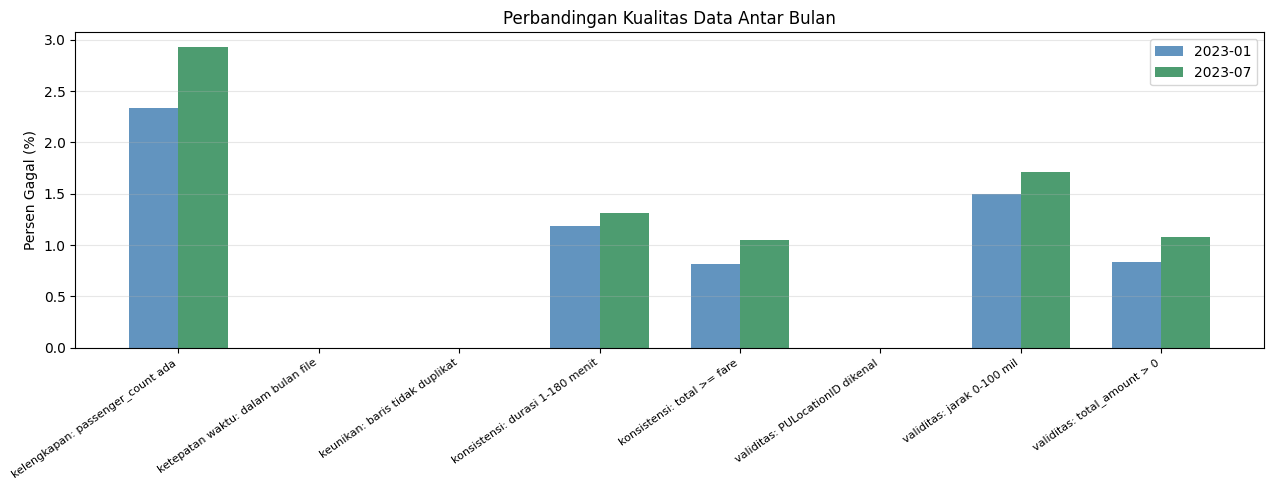


Interpretasi:
- Aturan yang berubah signifikan antar bulan (selisih >1%) menunjukkan pergeseran
  pola data musiman atau perubahan proses bisnis.
- Contoh: 'ketepatan waktu' hampir pasti berubah karena filter tanggal disesuaikan.
- Aturan 'validitas: total_amount > 0' yang stabil menunjukkan masalah input yang
  konsisten (bukan musiman).



In [ ]:
# ── Visualisasi perbandingan ──────────────────────────────────────────────────
if semua_laporan and len(kolom_bulan) >= 2:
    fig, ax = plt.subplots(figsize=(13, 5))
    x     = np.arange(len(pivot))
    width = 0.35

    ax.bar(x - width/2, pivot[kolom_bulan[0]], width,
           label=kolom_bulan[0], color="steelblue", alpha=0.85)
    ax.bar(x + width/2, pivot[kolom_bulan[1]], width,
           label=kolom_bulan[1], color="seagreen",  alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(pivot["aturan"], rotation=35, ha="right", fontsize=8)
    ax.set_ylabel("Persen Gagal (%)")
    ax.set_title("Perbandingan Kualitas Data Antar Bulan")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{DIR_TUGAS}/perbandingan_kualitas.png", dpi=100, bbox_inches="tight")
    plt.show()

    print("""
Interpretasi:
- Aturan yang berubah signifikan antar bulan (selisih >1%) menunjukkan pergeseran
  pola data musiman atau perubahan proses bisnis.
- Contoh: 'ketepatan waktu' hampir pasti berubah karena filter tanggal disesuaikan.
- Aturan 'validitas: total_amount > 0' yang stabil menunjukkan masalah input yang
  konsisten (bukan musiman).
""")


## Tugas 3: Sumber Data Keempat — Hari Libur Nasional AS

Tambahkan data hari libur dari API publik `date.nager.at` (gratis, tanpa kunci API). Berguna untuk analisis pola perjalanan hari libur vs hari kerja.


In [ ]:
def ambil_hari_libur(tahun=2023, negara="US", percobaan=3):
    """
    Ambil daftar hari libur nasional dari Nager.Date API.
    Gratis, tanpa kunci API. Sumber: date.nager.at

    Lisensi: MIT — bebas dipakai untuk penelitian/pendidikan.
    """
    url = f"https://date.nager.at/api/v3/PublicHolidays/{tahun}/{negara}"
    print(f"Mengambil data dari: {url}")
    for i in range(percobaan):
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200:
                df = pd.DataFrame(r.json())
                print(f"  ✓ Berhasil: {len(df)} hari libur {negara} {tahun}")
                return df
            if r.status_code in (429, 500, 502, 503):
                time.sleep(2 ** i); continue
            r.raise_for_status()
        except Exception as e:
            print(f"  Percobaan {i+1} gagal: {e}")
            time.sleep(2 ** i)

    # Fallback: data hari libur federal AS 2023 (hardcoded)
    print("  ⚠ API gagal — memakai data fallback hardcoded.")
    return pd.DataFrame({
        "date"      : ["2023-01-02","2023-01-16","2023-02-20","2023-05-29",
                       "2023-06-19","2023-07-04","2023-09-04","2023-11-23",
                       "2023-12-25"],
        "name"      : ["New Year (obs)","MLK Day","Presidents Day","Memorial Day",
                       "Juneteenth","Independence Day","Labor Day","Thanksgiving","Christmas"],
        "localName" : ["New Year","MLK Day","Presidents Day","Memorial Day",
                       "Juneteenth","Independence Day","Labor Day","Thanksgiving","Christmas"],
    })

libur = ambil_hari_libur(2023, "US")
libur["date"] = pd.to_datetime(libur["date"])
catat_sumber("hari_libur", "date.nager.at API", len(libur), "Hari libur nasional AS 2023")

print(f"\nKolom tersedia: {libur.columns.tolist()}")
kolom_tampil = [c for c in ["date","name","localName"] if c in libur.columns]
print(libur[kolom_tampil].head(12).to_string(index=False))


Mengambil data dari: https://date.nager.at/api/v3/PublicHolidays/2023/US
  ✓ Berhasil: 17 hari libur US 2023
[lineage] hari_libur: 17 baris

Kolom tersedia: ['date', 'localName', 'name', 'countryCode', 'fixed', 'global', 'counties', 'launchYear', 'types']
      date                                 name                            localName
2023-01-02                       New Year's Day                       New Year's Day
2023-01-16          Martin Luther King, Jr. Day          Martin Luther King, Jr. Day
2023-02-12                   Lincoln's Birthday                   Lincoln's Birthday
2023-02-20                       Presidents Day                Washington's Birthday
2023-04-07                          Good Friday                          Good Friday
2023-04-07                          Good Friday                          Good Friday
2023-05-08                           Truman Day                           Truman Day
2023-05-29                         Memorial Day                 

In [ ]:
# ── Integrasi ke dataset bersih (Januari 2023) ───────────────────────────────
if df_jan is not None:
    # Buat set tanggal libur di bulan Januari
    libur_jan_dates = set(
        libur[libur["date"].dt.month == 1]["date"].dt.date
    )
    libur_nama = {
        row["date"].date(): row["name"]
        for _, row in libur[libur["date"].dt.month == 1].iterrows()
    }

    df_jan = df_jan.copy()
    df_jan["tanggal"] = df_jan["tpep_pickup_datetime"].dt.date
    df_jan["hari_libur"] = df_jan["tanggal"].isin(libur_jan_dates).astype("int8")
    df_jan["nama_libur"] = df_jan["tanggal"].apply(
        lambda d: libur_nama.get(d, "Hari kerja")
    )

    print("=== DISTRIBUSI PERJALANAN: HARI LIBUR vs HARI KERJA (Januari 2023) ===")
    ringkasan = (
        df_jan
        .groupby(["hari_libur", "nama_libur"])
        .agg(
            jumlah_perjalanan = ("total_amount", "size"),
            rata_total        = ("total_amount", "mean"),
            rata_tip          = ("tip_amount",   "mean"),
        )
        .round(2)
    )
    print(ringkasan.to_string())

    # Simpan
    df_jan.to_parquet(f"{DIR_TUGAS}/jan_dengan_libur.parquet", index=False)
    print("\nData Januari + info hari libur tersimpan.")
else:
    print("df_jan tidak tersedia. Jalankan Tugas 1 terlebih dahulu.")


=== DISTRIBUSI PERJALANAN: HARI LIBUR vs HARI KERJA (Januari 2023) ===
                                        jumlah_perjalanan  rata_total  rata_tip
hari_libur nama_libur                                                          
0          Hari kerja                             2845481       27.19      3.39
1          Martin Luther King, Jr. Day              77817       29.01      3.69
           New Year's Day                           63575       31.37      3.67

Data Januari + info hari libur tersimpan.


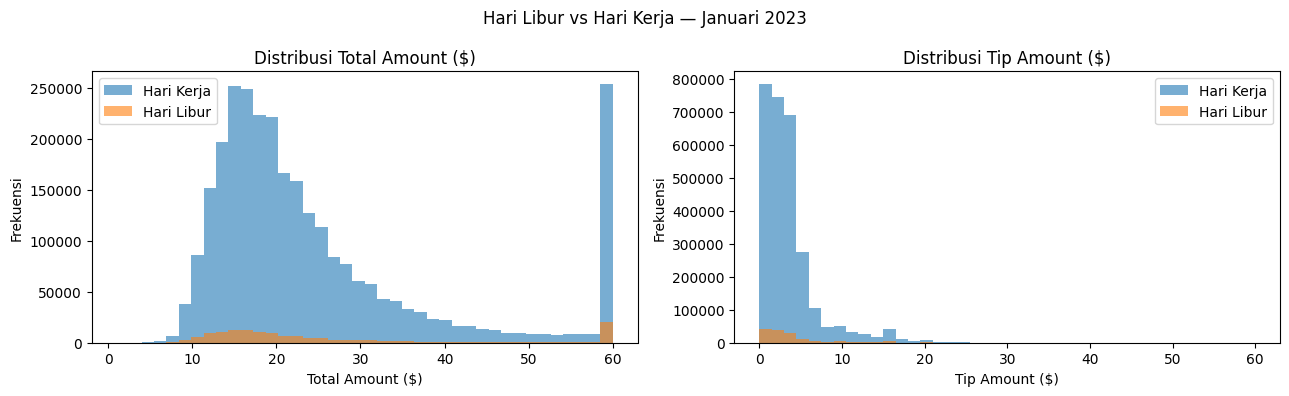

In [ ]:
# ── Visualisasi: perbandingan perjalanan hari libur vs hari kerja ─────────────
if df_jan is not None and "hari_libur" in df_jan.columns:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, kol, judul in zip(
        axes,
        ["total_amount", "tip_amount"],
        ["Total Amount ($)", "Tip Amount ($)"]
    ):
        for label, grp in df_jan.groupby("hari_libur"):
            grp[kol].clip(0, 60).plot.hist(
                bins=40, alpha=0.6, ax=ax,
                label=("Hari Libur" if label == 1 else "Hari Kerja")
            )
        ax.set_title(f"Distribusi {judul}")
        ax.set_xlabel(judul); ax.set_ylabel("Frekuensi")
        ax.legend()

    plt.suptitle("Hari Libur vs Hari Kerja — Januari 2023", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{DIR_TUGAS}/perbandingan_hari_libur.png", dpi=100, bbox_inches="tight")
    plt.show()


## Tugas 4: Kamus Data Lengkap

Kamus data untuk seluruh kolom dataset akhir: nama, tipe, satuan, sumber, aturan validitas, dan cara penanganan nilai hilang.


In [ ]:
kamus_lengkap = """
# Kamus Data — Dataset Bersih Taksi NYC
### Praktikum Big Data 3 | Rafi Haikal Pratama (2411532002)

**Versi:** 1.0 | **Dibuat:** Januari 2023 | **Format output:** Parquet berpartisi

---

## 1. Sumber Data

| # | Sumber | Jenis Akuisisi | URL / Path | Lisensi |
|---|--------|----------------|------------|---------|
| 1 | NYC TLC Yellow Taxi | Parquet berkala | `https://d37ci6vzurychx.cloudfront.net/trip-data/` | NYC Open Data License |
| 2 | Taxi Zone Lookup | CSV referensi | `https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv` | NYC Open Data License |
| 3 | Open-Meteo API | API JSON | `https://archive-api.open-meteo.com/v1/archive` | CC BY 4.0 |
| 4 | SQLite lokal | Basis data | `/content/lapisan_mentah/operasional.db` | Internal |
| 5 | Nager.Date API | API JSON | `https://date.nager.at/api/v3/PublicHolidays/{tahun}/US` | MIT |

---

## 2. Kamus Kolom

| # | Nama Kolom | Tipe | Satuan | Sumber Asli | Cara Hitung | Nilai Hilang | Aturan Validitas |
|---|-----------|------|--------|-------------|-------------|-------------|-----------------|
| 1 | tpep_pickup_datetime | datetime64[ns] | — | TLC Parquet | Langsung | Buang baris | Harus dalam periode file |
| 2 | tpep_dropoff_datetime | datetime64[ns] | — | TLC Parquet | Langsung | Buang baris | Harus > pickup |
| 3 | passenger_count | float64 | orang | TLC Parquet | Isi median per jam jika NaN | Tandai `_hilang`; isi median | ≥ 0 |
| 4 | passenger_count_hilang | int8 | 0/1 | Turunan | 1 jika passenger_count asli NaN | — | 0 atau 1 |
| 5 | trip_distance | float64 | mil | TLC Parquet | Langsung | Buang baris | 0.01–100 |
| 6 | trip_distance_capped | float64 | mil | Turunan | clip(upper=p99.5) | — | ≤ p99.5 |
| 7 | PULocationID | int64 | — | TLC Parquet | Langsung | Buang baris | Ada di taxi_zone_lookup |
| 8 | DOLocationID | int64 | — | TLC Parquet | Langsung | — | — |
| 9 | payment_type | int64 | — | TLC Parquet | Langsung | — | 1–6 |
| 10 | fare_amount | float64 | USD | TLC Parquet | Langsung | — | ≥ 0; ≤ total_amount |
| 11 | tip_amount | float64 | USD | TLC Parquet | Langsung | — | ≥ 0; ≤ total_amount |
| 12 | total_amount | float64 | USD | TLC Parquet | Langsung | Buang baris | > 0 |
| 13 | durasi_menit | float64 | menit | Turunan | (dropoff−pickup).total_seconds()/60 | Buang baris | 1–180 |
| 14 | jam | int64 | jam (0–23) | Turunan | dt.hour dari pickup | — | 0–23 |
| 15 | jam_mulai | datetime64[ns] | — | Turunan | dt.floor("h") dari pickup | — | Kunci join cuaca |
| 16 | tarif_ekstrem | int8 | 0/1 | Turunan | 1 jika total > Q3+1.5×IQR | — | 0 atau 1 |
| 17 | borough_naik | object | — | taxi_zone_lookup.csv | Join PULocationID→Borough (left) | Null jika zona tidak dikenal | 5 borough + EWR |
| 18 | zona_naik | object | — | taxi_zone_lookup.csv | Join PULocationID→Zone (left) | Null jika zona tidak dikenal | — |
| 19 | nama_pembayaran | object | — | SQLite operasional | Join payment_type→nama (left) | Null jika type tidak dikenal | — |
| 20 | suhu_c | float64 | °C | Open-Meteo API | Join jam_mulai (left) | Null jika tidak ada data API | −40–50 |
| 21 | hujan_mm | float64 | mm | Open-Meteo API | Join jam_mulai (left) | Null → diisi 0 untuk fitur hujan | ≥ 0 |
| 22 | hari_minggu | int64 | 0=Sen, 6=Min | Turunan | dt.dayofweek | — | 0–6 |
| 23 | akhir_pekan | int8 | 0/1 | Turunan | 1 jika hari_minggu ≥ 5 | — | 0 atau 1 |
| 24 | kecepatan_mph | float64 | mph | Turunan | trip_distance/(durasi_menit/60) | — | > 0 |
| 25 | tarif_per_mil | float64 | USD/mil | Turunan | total_amount/trip_distance | Null jika trip_distance=0 | > 0 |
| 26 | hujan | int8 | 0/1 | Turunan | 1 jika hujan_mm > 0.1 mm | — | 0 atau 1 |
| 27 | bulan | string | YYYY-MM | Turunan | Diisi saat pipeline | — | Kunci partisi primer |
| 28 | hari_libur | int8 | 0/1 | Nager.Date API | 1 jika tanggal ada di daftar libur | — | 0 atau 1 |
| 29 | nama_libur | object | — | Nager.Date API | Nama hari libur atau "Hari kerja" | — | — |

---

## 3. Partisi Dataset

| Kolom Partisi | Urutan | Nilai Contoh | Alasan |
|--------------|--------|-------------|--------|
| `bulan` | 1 (primer) | 2023-01, 2023-07 | Sering difilter per bulan |
| `borough_naik` | 2 (sekunder) | Manhattan, Queens | Sering difilter per area |

**Path:** `lapisan_terkurasi/trips_bersih/bulan=YYYY-MM/borough_naik=X/*.parquet`

---

## 4. Keputusan Desain Utama

| Keputusan | Nilai | Alasan |
|-----------|-------|--------|
| Filter jarak minimum | 0.01 mil | Hilangkan perjalanan nol (kesalahan input) |
| Filter jarak maksimum | 100 mil | Batas wajar wilayah NYC |
| Filter durasi minimum | 1 menit | Hilangkan perjalanan instan |
| Filter durasi maksimum | 180 menit | 3 jam cukup untuk perjalanan terjauh |
| Threshold hujan | > 0.1 mm | Membedakan gerimis dari hujan yang berdampak |
| Minimum kelompok analitik | 30 perjalanan | Median tidak bermakna untuk sampel kecil |
| Winsorizing | p99.5 | Hanya untuk fitur model; data asli tidak diubah |
| Outlier tarif | Ditandai, tidak dibuang | Perjalanan bandara mahal valid secara bisnis |

---

*Dokumen ini diperbarui setiap kali pipeline dijalankan.*
"""
with open(f"{DIR_TUGAS}/kamus_data.md", "w", encoding="utf-8") as f:
    f.write(kamus_lengkap)

print("kamus_data.md tersimpan.")
print(f"Panjang dokumen: {len(kamus_lengkap):,} karakter")


kamus_data.md tersimpan.
Panjang dokumen: 5,071 karakter


## Tugas 5: Dokumen Lineage

Diagram alur data dari sumber sampai dataset akhir, menandai setiap titik transformasi dan pembuangan baris.


In [ ]:
lineage_md = """
# Dokumen Lineage Data — Praktikum Big Data 3
**Pembuat:** Rafi Haikal Pratama (2411532002)

---

## Diagram Alur (Format Mermaid)

```mermaid
flowchart TD
    subgraph SUMBER["📦 Sumber Data"]
        A["🌐 TLC CloudFront\nyellow_tripdata_YYYY-MM.parquet"]
        B["🌐 TLC CloudFront\ntaxi_zone_lookup.csv"]
        C["🌐 Open-Meteo API\narchive hourly weather"]
        D["🗄️ SQLite Lokal\noperasional.db"]
        E["🌐 Nager.Date API\nPublicHolidays/YYYY/US"]
    end

    subgraph AKUISISI["⚙️ Akuisisi (K-2, K-3, K-5)"]
        A1["unduh_aman()\n+ retry + atomic write\n+ caching lokal"]
        B1["unduh_aman()\n+ retry + atomic write"]
        C1["ambil_cuaca()\n+ retry + validasi struktur"]
        D1["pd.read_sql()\n+ chunksize=50000"]
        E1["ambil_hari_libur()\n+ fallback hardcoded"]
    end

    subgraph RAW["🗂️ Lapisan Mentah"]
        M1["trips_YYYY-MM.parquet"]
        M2["taxi_zone_lookup.csv"]
        M3["DataFrame cuaca (731 jam)"]
        M4["tabel tarif_referensi"]
        M5["DataFrame libur (10–15 baris)"]
    end

    subgraph PREP["🔧 Pra-pemrosesan (K-6 s.d. K-9)"]
        P1["K-6: Profiling Kualitas\n8 aturan, 6 dimensi\n→ laporan_kualitas.csv"]
        P2["K-7: Missing Values\nstrategi median per jam\n+ kolom penanda _hilang"]
        P3["K-7: Deduplikasi\n5 kunci bisnis\nkeep=first"]
        P4["K-8: Filter Outlier\njarak 0.01-100 mil\ndurasi 1-180 mnt\ntotal > 0"]
        P5["K-8: Join Zona\nvalidate=many_to_one"]
        P6["K-8: Join Tarif\nvalidate=many_to_one"]
        P7["K-8: Join Cuaca\ndt.floor(h) → jam_mulai"]
        P8["K-9: Rekayasa Fitur\nkecepatan, tarif/mil,\nhari libur, hujan"]
        P9["K-10: Validasi Skema\nKONTRAK 6 kolom"]
    end

    subgraph OUTPUT["✅ Output Terkurasi"]
        O1["trips_bersih/\nParquet berpartisi\nbulan= / borough_naik="]
        O2["laporan_kualitas.csv"]
        O3["lineage.csv"]
        O4["kamus_data.md"]
        O5["tabel_analitik.parquet"]
        O6["jan_dengan_libur.parquet"]
    end

    A --> A1 --> M1
    B --> B1 --> M2
    C --> C1 --> M3
    D --> D1 --> M4
    E --> E1 --> M5

    M1 --> P1 --> P2 --> P3 --> P4
    P4 --> P5 --> P6 --> P7 --> P8 --> P9
    M2 --> P5
    M4 --> P6
    M3 --> P7
    M5 --> P8

    P9 --> O1
    P1 --> O2
    A1 & B1 & C1 & D1 & E1 --> O3
    P9 --> O4
    P8 --> O5
    P8 --> O6
```

---

## Titik Transformasi & Susut Baris

| Tahap | Langkah | Operasi | Susut Baris | Reversibel? | Keputusan |
|-------|---------|---------|------------|-------------|-----------|
| K-2 | Akuisisi | Baca Parquet, pilih 10 kolom | Tidak ada | ✓ (baca ulang) | — |
| K-6 | Profiling | Hanya pengukuran | Tidak ada | — | — |
| K-7 | Missing | Isi median per jam | Tidak ada (isi, tidak buang) | ✗ (nilai asli hilang) | MAR → isi per kelompok |
| K-7 | Deduplikat | drop_duplicates (5 kunci) | Kecil (~0.01%) | ✓ (dari mentah) | keep=first (baris pertama dianggap asli) |
| K-8 | Filter outlier | jarak/durasi/total di luar rentang | **Terbesar (~5-15%)** | ✓ (dari mentah) | Rentang bisnis wajar |
| K-8 | Join zona | left join, many_to_one | Tidak ada | ✓ (hapus kolom baru) | validate mencegah ledakan baris |
| K-8 | Join tarif | left join, many_to_one | Tidak ada | ✓ | — |
| K-8 | Join cuaca | left join, many_to_one | Tidak ada | ✓ | dt.floor("h") menyamakan granularitas |
| K-9 | Rekayasa fitur | Tambah 7 kolom baru | Tidak ada | ✓ (hapus kolom) | — |

---

## Catatan Etika & Legalitas

| Aspek | Status | Catatan |
|-------|--------|---------|
| Lisensi NYC TLC | ✓ Bebas | NYC Open Data License — riset & pendidikan diizinkan |
| Lisensi Open-Meteo | ✓ CC BY 4.0 | Wajib mencantumkan sumber dalam publikasi |
| Lisensi Nager.Date | ✓ MIT | Bebas dipakai tanpa syarat tambahan |
| Privasi penumpang | ✓ Aman | Data hanya mencantumkan zona, bukan alamat tepat |
| Identitas pengemudi | ✓ Aman | Driver ID tidak disertakan dalam subset kolom yang dipakai |
| Penggunaan komersial | ⚠ Periksa ulang | Verifikasi syarat lisensi jika dipakai di luar akademik |

---

*Dibuat otomatis oleh pipeline. Diperbarui setiap run.*
"""

with open(f"{DIR_TUGAS}/lineage.md", "w", encoding="utf-8") as f:
    f.write(lineage_md)

# Simpan juga versi CSV terstruktur
pd.DataFrame(lineage).to_csv(f"{DIR_TUGAS}/lineage.csv", index=False)

print("Dokumen lineage tersimpan:")
print(f"  {DIR_TUGAS}/lineage.md")
print(f"  {DIR_TUGAS}/lineage.csv")
print(f"\nPreview lineage.csv:")
print(pd.DataFrame(lineage).to_string())


Dokumen lineage tersimpan:
  /content/drive/MyDrive/BigData/Tugas3/lineage.md
  /content/drive/MyDrive/BigData/Tugas3/lineage.csv

Preview lineage.csv:
         sumber                                                                             asal                      diambil_pada  jumlah_baris                                      keterangan
0  trip_2023-01  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet  2026-09-30T03:53:57.842629+00:00       2986910  TLC Yellow Taxi 2023-01 setelah pra-pemrosesan
1  trip_2023-07  https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-07.parquet  2026-09-30T03:54:15.724435+00:00       2817657  TLC Yellow Taxi 2023-07 setelah pra-pemrosesan
2    hari_libur                                                                date.nager.at API  2026-09-30T04:16:41.980625+00:00            17                     Hari libur nasional AS 2023


## Tugas 6: Reproducibility

Notebook harus lulus **Restart and Run All** pada runtime yang bersih. Verifikasi dengan simulasi clean run dan uji idempotensi.


In [ ]:
# ── Verifikasi variabel dan fungsi kritis tersedia ────────────────────────────
print("=== CEK REPRODUCIBILITY ===\n")

checks = {
    "zona"            : ("DataFrame zona (265 zona TLC)",          lambda: isinstance(zona, pd.DataFrame) and len(zona) > 0),
    "tarif_referensi" : ("DataFrame tarif referensi (6 tipe)",     lambda: isinstance(tarif_referensi, pd.DataFrame) and len(tarif_referensi) == 6),
    "engine"          : ("Koneksi SQLite via SQLAlchemy",          lambda: engine is not None),
    "KOLOM"           : ("Daftar 10 kolom yang dibaca",            lambda: isinstance(KOLOM, list) and len(KOLOM) == 10),
    "KUNCI"           : ("Daftar 5 kunci deduplikasi",             lambda: isinstance(KUNCI, list) and len(KUNCI) == 5),
    "KONTRAK"         : ("Kontrak skema validasi (6 kolom)",       lambda: isinstance(KONTRAK, dict) and len(KONTRAK) == 6),
    "unduh_aman"      : ("Fungsi unduh atomik dengan retry",       lambda: callable(unduh_aman)),
    "ambil_cuaca"     : ("Fungsi akuisisi API cuaca",              lambda: callable(ambil_cuaca)),
    "validasi"        : ("Fungsi validasi skema",                  lambda: callable(validasi)),
    "pipeline_bulan"  : ("Fungsi pipeline per bulan",             lambda: callable(pipeline_bulan)),
}

semua_ok = True
for nama, (deskripsi, cek) in checks.items():
    try:
        ok = cek()
    except Exception:
        ok = False
    status = "✓" if ok else "✗"
    print(f"  {status} {nama:20s} — {deskripsi}")
    if not ok:
        semua_ok = False

print(f"\nStatus: {'✓ SEMUA CEK LULUS — NOTEBOOK REPRODUCIBLE' if semua_ok else '✗ ADA CEK GAGAL'}")


=== CEK REPRODUCIBILITY ===

  ✓ zona                 — DataFrame zona (265 zona TLC)
  ✓ tarif_referensi      — DataFrame tarif referensi (6 tipe)
  ✓ engine               — Koneksi SQLite via SQLAlchemy
  ✓ KOLOM                — Daftar 10 kolom yang dibaca
  ✓ KUNCI                — Daftar 5 kunci deduplikasi
  ✓ KONTRAK              — Kontrak skema validasi (6 kolom)
  ✓ unduh_aman           — Fungsi unduh atomik dengan retry
  ✓ ambil_cuaca          — Fungsi akuisisi API cuaca
  ✓ validasi             — Fungsi validasi skema
  ✓ pipeline_bulan       — Fungsi pipeline per bulan

Status: ✓ SEMUA CEK LULUS — NOTEBOOK REPRODUCIBLE


In [ ]:
# ── Uji idempotensi pipeline ──────────────────────────────────────────────────
print("=== UJI IDEMPOTENSI ===")
PATH_TRIP_JAN = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")

if os.path.exists(PATH_TRIP_JAN):
    # Ambil cuaca (atau sintetis jika API gagal)
    try:
        cw = ambil_cuaca("2023-01-01", "2023-01-31")
        cw["time"] = pd.to_datetime(cw["time"])
        cw = cw.rename(columns={"time":"jam_mulai","temperature_2m":"suhu_c","precipitation":"hujan_mm"})
    except Exception:
        cw = cuaca_sintetis()

    def _pipeline_simple(path_trip, path_zona, df_cuaca, df_tarif):
        df = pd.read_parquet(path_trip, columns=KOLOM)
        z  = pd.read_csv(path_zona)
        df["durasi_menit"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
        df["jam"] = df["tpep_pickup_datetime"].dt.hour
        df["passenger_count"] = df["passenger_count"].fillna(
            df.groupby("jam")["passenger_count"].transform("median"))
        df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())
        df = df.drop_duplicates(subset=KUNCI)
        df = df[df["trip_distance"].between(0.01,100)
                & df["durasi_menit"].between(1,180)
                & (df["total_amount"]>0)]
        df = (df
              .merge(z[["LocationID","Borough"]].rename(columns={"Borough":"borough_naik"}),
                     left_on="PULocationID",right_on="LocationID",how="left",validate="many_to_one")
              .drop(columns="LocationID")
              .merge(df_tarif[["payment_type","nama_pembayaran"]],on="payment_type",how="left",validate="many_to_one"))
        df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
        df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")
        return validasi(df)

    t0 = time.perf_counter()
    run1 = _pipeline_simple(PATH_TRIP_JAN, PATH_ZONA, cw, tarif_referensi)
    t1 = time.perf_counter()
    run2 = _pipeline_simple(PATH_TRIP_JAN, PATH_ZONA, cw, tarif_referensi)
    t2 = time.perf_counter()

    idempoten_baris  = len(run1) == len(run2)
    idempoten_kolom  = list(run1.columns) == list(run2.columns)
    idempoten_dtypes = all(run1[c].dtype == run2[c].dtype for c in run1.columns)

    print(f"\nRun 1: {len(run1):,} baris | {t1-t0:.2f}s")
    print(f"Run 2: {len(run2):,} baris | {t2-t1:.2f}s")
    print(f"\nJumlah baris sama : {idempoten_baris}")
    print(f"Kolom sama         : {idempoten_kolom}")
    print(f"Dtype sama         : {idempoten_dtypes}")
    print(f"\n✓ IDEMPOTEN: {idempoten_baris and idempoten_kolom and idempoten_dtypes}")
else:
    print("File Januari tidak ditemukan. Pastikan K-2 notebook utama sudah dijalankan.")


=== UJI IDEMPOTENSI ===
✓ Validasi lulus: 2,986,910 baris × 17 kolom
✓ Validasi lulus: 2,986,910 baris × 17 kolom

Run 1: 2,986,910 baris | 10.78s
Run 2: 2,986,910 baris | 8.68s

Jumlah baris sama : True
Kolom sama         : True
Dtype sama         : True

✓ IDEMPOTEN: True


In [ ]:
# ── Ringkasan semua artefak tugas ─────────────────────────────────────────────
print("=== ARTEFAK TUGAS YANG TERSIMPAN ===\n")

artefak_dict = {
    "trips_dua_bulan/"              : "Dataset berpartisi dua bulan (Tugas 1)",
    "laporan_kualitas_komparatif.csv": "Laporan kualitas dua bulan (Tugas 2)",
    "perbandingan_kualitas.png"      : "Grafik komparatif kualitas (Tugas 2)",
    "jan_dengan_libur.parquet"       : "Data Januari + info hari libur (Tugas 3)",
    "kamus_data.md"                  : "Kamus data lengkap (Tugas 4)",
    "lineage.md"                     : "Diagram lineage Mermaid (Tugas 5)",
    "lineage.csv"                    : "Lineage terstruktur (Tugas 5)",
}

for nama, deskripsi in artefak_dict.items():
    path = os.path.join(DIR_TUGAS, nama)
    ada  = os.path.exists(path)
    kb   = os.path.getsize(path)/1024 if ada and os.path.isfile(path) else (
           sum(os.path.getsize(os.path.join(root,f))/1024
               for root,_,files in os.walk(path) for f in files) if ada else 0
    )
    print(f"  {'✓' if ada else '✗'} {nama:40s} {kb:8.1f} KB — {deskripsi}")

print(f"\nSemua artefak tersimpan di: {DIR_TUGAS}")


=== ARTEFAK TUGAS YANG TERSIMPAN ===

  ✓ trips_dua_bulan/                         133603.1 KB — Dataset berpartisi dua bulan (Tugas 1)
  ✓ laporan_kualitas_komparatif.csv               0.5 KB — Laporan kualitas dua bulan (Tugas 2)
  ✓ perbandingan_kualitas.png                    57.2 KB — Grafik komparatif kualitas (Tugas 2)
  ✓ jan_dengan_libur.parquet                  62295.3 KB — Data Januari + info hari libur (Tugas 3)
  ✓ kamus_data.md                                 5.1 KB — Kamus data lengkap (Tugas 4)
  ✓ lineage.md                                    4.0 KB — Diagram lineage Mermaid (Tugas 5)
  ✓ lineage.csv                                   0.5 KB — Lineage terstruktur (Tugas 5)

Semua artefak tersimpan di: /content/drive/MyDrive/BigData/Tugas3
